In [1]:
from resources.imports import *

from resources.lattices import geometry, pStrainProperties, effProperties
from resources.MLdata import DATA, load_data, prep_UTdata, prep_FTdata, remove_outliers, split_data, save_MLdata, \
                             plot_sampling, locSims, get_stats, plot_frequency, plot_properties, plot_curve

In [2]:
### Global Inputs

mode = ("compare", "Target-xs")

DAT = DATA(path=1, 
           path_add="",
           LAT="tri", 
           dis="disNodes", 
           dN=0.2)

if mode is not None:
    if mode[0].lower() == "compare":
        DAT = DATA(path=1, 
           path_add="",
           LAT=DAT.LAT, 
           dis=DAT.dis, 
           dN=DAT.dN)
        
        DATc = DATA(path=1, 
           path_add=mode[1],
           LAT=DAT.LAT, 
           dis=DAT.dis, 
           dN=DAT.dN)

l = 0.010
if DAT.LAT.lower() == "fcc":
    nnx = 16
    MODEL = "ductile"
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "kagome":
    nnx = 20
    MODEL = "both"
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "hex":
    nnx = 20
    MODEL = "both"
    manual_outliersUT = None
    manual_outliersFT = [175]
elif DAT.LAT.lower() == "tri":
    nnx = 30
    MODEL = "both"
    manual_outliersUT = None
    manual_outliersFT = None

MODEL = MODEL      # ductile, fracture, both

# Load Data

In [3]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    DAT.UT_CSVin  = DAT.PATH + f'Ductile-{DAT.dis}-IN.csv'
    DAT.UT_CSVout = DAT.PATH + f'Ductile-{DAT.dis}-OUT.csv'
    DAT.UT_CSVin_f = None
    if DAT.freq:
        DAT.UT_CSVin_f = DAT.PATH + f'Ductile-{DAT.dis}-INf.csv'

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    DAT.FT_CSVin  = DAT.PATH + f'Fracture-{DAT.dis}-IN.csv'
    DAT.FT_CSVout = DAT.PATH + f'Fracture-{DAT.dis}-OUT.csv'
    DAT.FT_CSVin_f = None
    if DAT.freq:
        DAT.FT_CSVin_f = DAT.PATH + f'Fracture-{DAT.dis}-INf.csv'

if mode is not None and mode[0].lower() == "compare":
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        DATc.UT_CSVin  = DATc.PATH + f'Ductile-{DATc.dis}-IN.csv'
        DATc.UT_CSVout = DATc.PATH + f'Ductile-{DATc.dis}-OUT.csv'
        DATc.UT_CSVin_f = None
        if DATc.freq:
            DATc.UT_CSVin_f = DATc.PATH + f'Ductile-{DATc.dis}-INf.csv'

    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        DATc.FT_CSVin  = DATc.PATH + f'Fracture-{DATc.dis}-IN.csv'
        DATc.FT_CSVout = DATc.PATH + f'Fracture-{DATc.dis}-OUT.csv'
        DATc.FT_CSVin_f = None
        if DATc.freq:
            DATc.FT_CSVin_f = DATc.PATH + f'Fracture-{DATc.dis}-INf.csv'

In [4]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_INf_df, DAT.UT_perINr_df, DAT.UT_perIN_df, DAT.UT_perOUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df = load_data(DAT.UT_CSVin, DAT.UT_CSVout, DAT.UT_CSVin_f)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_INf_df, DAT.FT_perINr_df, DAT.FT_perIN_df, DAT.FT_perOUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df = load_data(DAT.FT_CSVin, DAT.FT_CSVout, DAT.FT_CSVin_f)

if mode is not None and mode[0].lower() == "compare":
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_INf_df, DATc.UT_perINr_df, DATc.UT_perIN_df, DATc.UT_perOUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df = load_data(DATc.UT_CSVin, DATc.UT_CSVout, DATc.UT_CSVin_f)

    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_INf_df, DATc.FT_perINr_df, DATc.FT_perIN_df, DATc.FT_perOUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df = load_data(DATc.FT_CSVin, DATc.FT_CSVout, DATc.FT_CSVin_f)

# Geometry

In [5]:
geom = geometry(DAT.LAT, l, nnx, FTcalc=True)

E = 123e9  ## Pa
v = 0.3
rD = 0.2
E_pStrain, v_pStrain = pStrainProperties(E, v)
E_eff, v_eff = effProperties(DAT.LAT, E_pStrain, rD)

# Prep Data

In [6]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    DAT.UT_dIN_r, DAT.UT_dOUT_r, DAT.UT_INf_r, DAT.UT_xOUT, DAT.UT_props_r = prep_UTdata(DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_perOUT_df, DAT.UT_OUT_df, DAT.UT_INf_df)
    DAT.UT_dIN, DAT.UT_dOUT, DAT.UT_INf, DAT.UT_props, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_INf_df = remove_outliers(DAT.UT_dIN_r, DAT.UT_dOUT_r, DAT.UT_props_r, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_INf_r, DAT.UT_INf_df, manual=manual_outliersUT)
    DAT.UT_train, DAT.UT_val, DAT.UT_test = split_data(DAT.UT_dIN[1:], DAT.UT_dOUT[1:], DAT.UT_props, DAT.UT_INf, split=0.85)
    save_MLdata(DAT.UT_perIN_df, DAT.UT_perOUT_df, DAT.UT_train, DAT.UT_val, DAT.UT_test, DAT.PATH, "UT", DAT.dis)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    DAT.FT_dIN_r, DAT.FT_dOUT_r, DAT.FT_INf_r, DAT.FT_xOUT, DAT.FT_props_r = prep_FTdata(DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_perOUT_df, DAT.FT_OUT_df, geom, E_eff, DAT.FT_INf_df)
    DAT.FT_dIN, DAT.FT_dOUT, DAT.FT_INf, DAT.FT_props, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_INf_df = remove_outliers(DAT.FT_dIN_r, DAT.FT_dOUT_r, DAT.FT_props_r, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_INf_r, DAT.FT_INf_df, manual=manual_outliersFT)
    DAT.FT_train, DAT.FT_val, DAT.FT_test = split_data(DAT.FT_dIN[1:], DAT.FT_dOUT[1:], DAT.FT_props, DAT.FT_INf, split=0.85)
    save_MLdata(DAT.FT_perIN_df, DAT.FT_perOUT_df, DAT.FT_train, DAT.FT_val, DAT.FT_test, DAT.PATH, "FT", DAT.dis)

if mode is not None and mode[0].lower() == "compare":
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        DATc.UT_dIN_r, DATc.UT_dOUT_r, DATc.UT_INf_r, DATc.UT_xOUT, DATc.UT_props_r = prep_UTdata(DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_perOUT_df, DATc.UT_OUT_df, DATc.UT_INf_df)
        DATc.UT_dIN, DATc.UT_dOUT, DATc.UT_INf, DATc.UT_props, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_INf_df = remove_outliers(DATc.UT_dIN_r, DATc.UT_dOUT_r, DATc.UT_props_r, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_INf_r, DATc.UT_INf_df, manual=manual_outliersFT)
        DATc.UT_train, DATc.UT_val, DATc.UT_test = split_data(DATc.UT_dIN[1:], DATc.UT_dOUT[1:], DATc.UT_props, DATc.UT_INf, split=0.85)
        save_MLdata(DATc.UT_perIN_df, DATc.UT_perOUT_df, DATc.UT_train, DATc.UT_val, DATc.UT_test, DATc.PATH, "UT", DATc.dis)
    
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        DATc.FT_dIN_r, DATc.FT_dOUT_r, DATc.FT_INf_r, DATc.FT_xOUT, DATc.FT_props_r = prep_FTdata(DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_perOUT_df, DATc.FT_OUT_df, geom, E_eff, DATc.FT_INf_df)
        DATc.FT_dIN, DATc.FT_dOUT, DATc.FT_INf, DATc.FT_props, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_INf_df = remove_outliers(DATc.FT_dIN_r, DATc.FT_dOUT_r, DATc.FT_props_r, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_INf_r, DATc.FT_INf_df, manual=manual_outliersFT)
        DATc.FT_train, DATc.FT_val, DATc.FT_test = split_data(DATc.FT_dIN[1:], DATc.FT_dOUT[1:], DATc.FT_props, DATc.FT_INf, split=0.85)
        save_MLdata(DATc.FT_perIN_df, DATc.FT_perOUT_df, DATc.FT_train, DATc.FT_val, DATc.FT_test, DATc.PATH, "FT", DATc.dis)

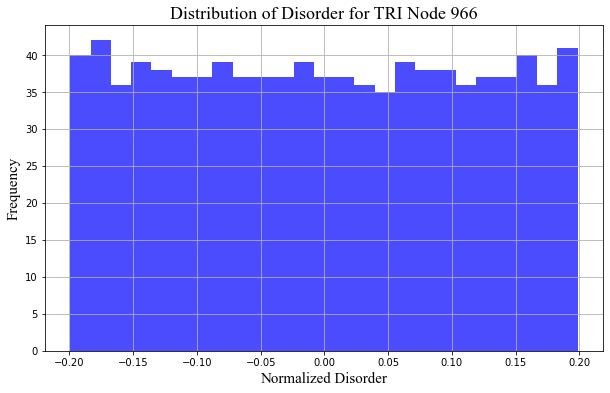

In [7]:
plot_sampling(DAT.UT_dIN_df, DAT.LAT, l, indx=None, num=1, by="Node")

In [8]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    DAT.UT_stats = get_stats(DAT.UT_props)
    DAT.UT_nSim_max1, DAT.UT_nSim_min1 = locSims(DAT.UT_props[0], DAT.UT_OUT_df)
    DAT.UT_nSim_max2, DAT.UT_nSim_min2 = locSims(DAT.UT_props[1], DAT.UT_OUT_df)
    DAT.UT_nSim_max3, DAT.UT_nSim_min3 = locSims(DAT.UT_props[2], DAT.UT_OUT_df)
    DAT.UT_nSim_max12, DAT.UT_nSim_min12 = locSims(DAT.UT_props[0]/DAT.UT_props[0,0]+DAT.UT_props[1]/DAT.UT_props[1,0], DAT.UT_OUT_df)
    print("FINAL SIMULATION COUNT:", len(DAT.UT_OUT_df)-1)
    print(f" UT-D     -- max: {DAT.UT_nSim_max1}, min: {DAT.UT_nSim_min1}    Stats: {np.array(DAT.UT_stats[0])/DAT.UT_props[0,0]}")
    print(f" UT-Str   -- max: {DAT.UT_nSim_max2}, min: {DAT.UT_nSim_min2}    Stats: {np.array(DAT.UT_stats[1])/DAT.UT_props[1,0]}")
    print(f" UT-Sti   -- max: {DAT.UT_nSim_max3}, min: {DAT.UT_nSim_min3}    Stats: {np.array(DAT.UT_stats[2])/DAT.UT_props[2,0]}")
    print(f" UT-D+Str -- max: {DAT.UT_nSim_max12}, min: {DAT.UT_nSim_min12} \n")

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    DAT.FT_stats = get_stats(DAT.FT_props)
    DAT.FT_nSim_max1, DAT.FT_nSim_min1 = locSims(DAT.FT_props[0], DAT.FT_OUT_df)
    DAT.FT_nSim_max2, DAT.FT_nSim_min2 = locSims(DAT.FT_props[2], DAT.FT_OUT_df)
    DAT.FT_nSim_max3, DAT.FT_nSim_min3 = locSims(DAT.FT_props[3], DAT.FT_OUT_df)
    DAT.FT_nSim_max13, DAT.FT_nSim_min13 = locSims(DAT.FT_props[0]/DAT.FT_props[0,0]+DAT.FT_props[3]/DAT.FT_props[3,0], DAT.FT_OUT_df)
    print("FINAL SIMULATION COUNT:", len(DAT.FT_OUT_df)-1)
    print(f" FT-K   -- max: {DAT.FT_nSim_max1}, min: {DAT.FT_nSim_min1}    Stats: {np.array(DAT.FT_stats[0])/DAT.FT_props[0,0]}")
    print(f" FT-F   -- max: {DAT.FT_nSim_max2}, min: {DAT.FT_nSim_min2}    Stats: {np.array(DAT.FT_stats[2])/DAT.FT_props[2,0]}")
    print(f" FT-D   -- max: {DAT.FT_nSim_max3}, min: {DAT.FT_nSim_min3}    Stats: {np.array(DAT.FT_stats[3])/DAT.FT_props[3,0]}")
    print(f" FT-K+D -- max: {DAT.FT_nSim_max13}, min: {DAT.FT_nSim_min13} \n")

if mode is not None and mode[0].lower() == "compare":
    print("\n=============== COMPARISON DATA ===============\n")
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        DATc.UT_stats = get_stats(DATc.UT_props)
        DATc.UT_nSim_max1, DATc.UT_nSim_min1 = locSims(DATc.UT_props[0], DATc.UT_OUT_df)
        DATc.UT_nSim_max2, DATc.UT_nSim_min2 = locSims(DATc.UT_props[1], DATc.UT_OUT_df)
        DATc.UT_nSim_max3, DATc.UT_nSim_min3 = locSims(DATc.UT_props[2], DATc.UT_OUT_df)
        DATc.UT_nSim_max12, DATc.UT_nSim_min12 = locSims(DATc.UT_props[0]/DATc.UT_props[0,0]+DATc.UT_props[1]/DATc.UT_props[1,0], DATc.UT_OUT_df)
        print("FINAL SIMULATION COUNT:", len(DATc.UT_OUT_df)-1)
        print(f" UT-D     -- max: {DATc.UT_nSim_max1}, min: {DATc.UT_nSim_min1}    Stats: {np.array(DATc.UT_stats[0])/DATc.UT_props[0,0]}")
        print(f" UT-Str   -- max: {DATc.UT_nSim_max2}, min: {DATc.UT_nSim_min2}    Stats: {np.array(DATc.UT_stats[1])/DATc.UT_props[1,0]}")
        print(f" UT-Sti   -- max: {DATc.UT_nSim_max3}, min: {DATc.UT_nSim_min3}    Stats: {np.array(DATc.UT_stats[2])/DATc.UT_props[2,0]}")
        print(f" UT-D+Str -- max: {DATc.UT_nSim_max12}, min: {DATc.UT_nSim_min12} \n")

    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        DATc.FT_stats = get_stats(DATc.FT_props)
        DATc.FT_nSim_max1, DATc.FT_nSim_min1 = locSims(DATc.FT_props[0], DATc.FT_OUT_df)
        DATc.FT_nSim_max2, DATc.FT_nSim_min2 = locSims(DATc.FT_props[2], DATc.FT_OUT_df)
        DATc.FT_nSim_max3, DATc.FT_nSim_min3 = locSims(DATc.FT_props[3], DATc.FT_OUT_df)
        DATc.FT_nSim_max13, DATc.FT_nSim_min13 = locSims(DATc.FT_props[0]/DATc.FT_props[0,0]+DATc.FT_props[3]/DATc.FT_props[3,0], DATc.FT_OUT_df)
        print("FINAL SIMULATION COUNT:", len(DATc.FT_OUT_df)-1)
        print(f" FT-K   -- max: {DATc.FT_nSim_max1}, min: {DATc.FT_nSim_min1}    Stats: {np.array(DATc.FT_stats[0])/DATc.FT_props[0,0]}")
        print(f" FT-F   -- max: {DATc.FT_nSim_max2}, min: {DATc.FT_nSim_min2}    Stats: {np.array(DATc.FT_stats[2])/DATc.FT_props[2,0]}")
        print(f" FT-D   -- max: {DATc.FT_nSim_max3}, min: {DATc.FT_nSim_min3}    Stats: {np.array(DATc.FT_stats[3])/DATc.FT_props[3,0]}")
        print(f" FT-K+D -- max: {DATc.FT_nSim_max13}, min: {DATc.FT_nSim_min13} \n")

FINAL SIMULATION COUNT: 944
 UT-D     -- max: 655, min: 23    Stats: [0.59014091 0.0470826 ]
 UT-Str   -- max: 642, min: 863    Stats: [0.90796048 0.0099115 ]
 UT-Sti   -- max: 776, min: 274    Stats: [0.95561018 0.00315272]
 UT-D+Str -- max: 655, min: 561 

FINAL SIMULATION COUNT: 986
 FT-K   -- max: 436, min: 429    Stats: [0.80151419 0.11206735]
 FT-F   -- max: 886, min: 357    Stats: [0.86196298 0.05705004]
 FT-D   -- max: 436, min: 429    Stats: [0.80356571 0.14351552]
 FT-K+D -- max: 436, min: 429 


=============== COMPARISON DATA ===============

FINAL SIMULATION COUNT: 992
 UT-D     -- max: 673, min: 47    Stats: [0.74200581 0.04919933]
 UT-Str   -- max: 818, min: 612    Stats: [0.9567796  0.00879315]
 UT-Sti   -- max: 450, min: 189    Stats: [0.99210997 0.00100436]
 UT-D+Str -- max: 673, min: 446 

FINAL SIMULATION COUNT: 983
 FT-K   -- max: 298, min: 24    Stats: [1.00338371 0.01182794]
 FT-F   -- max: 444, min: 961    Stats: [0.99397974 0.00411217]
 FT-D   -- max: 285, min:

In [9]:
# FT_OUT_df.index.get_loc(FT_OUT_df[FT_OUT_df.index == 182].index[0])

# Plot Distribution & Identify Max, Min Simulations

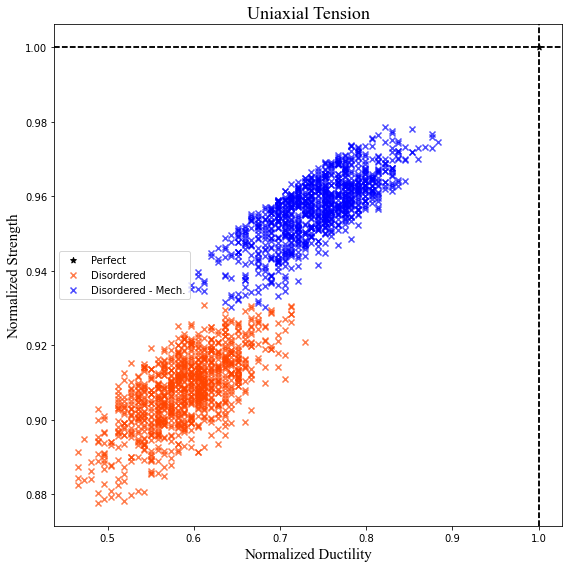

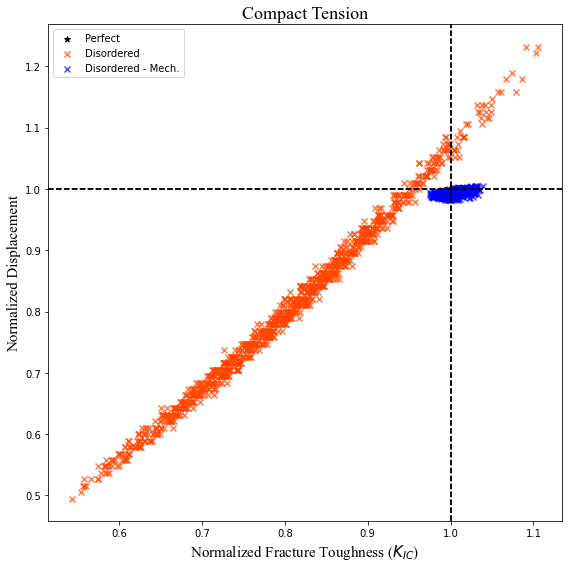

In [10]:
plot_props = True
plot_freq = False
plot_ONLY_freq = False

dduct, sstr, sstiff = 0, 1, 2
kk, FF, dd = 0, 2, 3

U1, U2 = dduct, sstr
F1, F2 = kk, dd

if plot_props:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        fig, ax = plot_properties(DAT.UT_props[U1], DAT.UT_props[U2], "UT", include_freq=plot_freq, compare_ax=None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.UT_props[U1], DATc.UT_props[U2], "UT", include_freq=plot_freq, compare_ax=(fig, ax))
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        fig, ax = plot_properties(DAT.FT_props[F1], DAT.FT_props[F2], "FT", include_freq=plot_freq, compare_ax=None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.FT_props[U1], DATc.FT_props[U2], "FT", include_freq=plot_freq, compare_ax=(fig, ax))
    plt.show()

if plot_ONLY_freq:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        plot_frequency(DAT.UT_props_r[U1], DAT.UT_props[U1], "UT", bins=30)
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        plot_frequency(DAT.FT_props_r[F1], DAT.FT_props[F1], "FT", bins=30)

# Plots UT and FT Curves

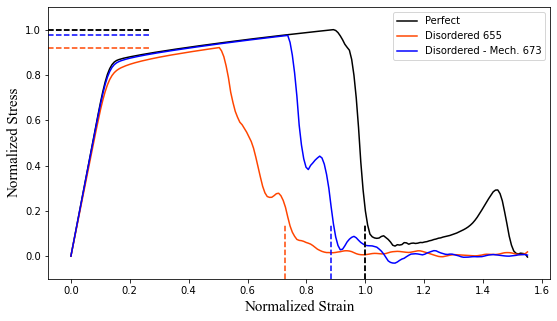

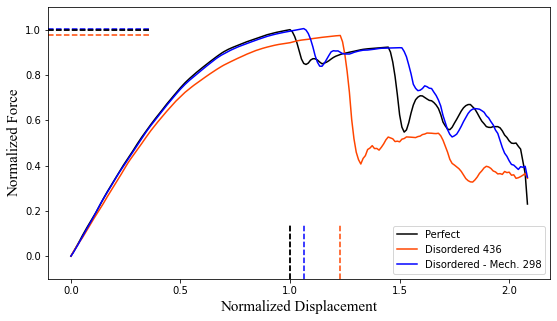

In [11]:
# [UT_nSim_max1, UT_nSim_min1, UT_nSim_max2, UT_nSim_min2, UT_nSim_max3, UT_nSim_min3, UT_nSim_max12, UT_nSim_min12]
# [FT_nSim_max1, FT_nSim_min1, FT_nSim_max2, FT_nSim_min2, FT_nSim_max3, FT_nSim_min3, FT_nSim_max13, FT_nSim_min13]
idx = None
q   = "all"
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    fig2, ax1 = plot_curve(DAT.UT_OUT_df, DAT.UT_xOUT, "ut", pi=0, idx=[DAT.UT_nSim_max1], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.UT_OUT_df, DATc.UT_xOUT, "ut", pi=0, idx=[DATc.UT_nSim_max1], q='all', compare_ax=(fig2, ax1))
    
if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    fig2, ax1 = plot_curve(DAT.FT_OUT_df, DAT.FT_xOUT, "ft", pi=0, idx=[DAT.FT_nSim_max1], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.FT_OUT_df, DATc.FT_xOUT, "ft", pi=0, idx=[DATc.FT_nSim_max1], q='all', compare_ax=(fig2, ax1))